# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-IEMOCAP https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [19]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import (
    model_name_to_slug
)

# --- data paths ---
DATASET_ID = "iemocap_4class"
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / DATASET_ID
AUDIO_DIR = RAW_DIR / "audio"

# --- feature extraction infos ---
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024) # (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)

SPLIT_STRATEGY = "sample_stratified"
#SPLIT_STRATEGY = "speaker_independent" # each split has different voice actors

# --- output artifacts naming ---
FEATURE_RUN_ID = f"{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{FEATURE_POOLING}"
BLACK_BOX_RUN_ID = f"blackbox_{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{SPLIT_STRATEGY}"
BLACK_BOX_EMBEDDING_RUN_ID = f"{BLACK_BOX_RUN_ID}_penultimate_l2"
PROTOTYPE_CLUSTERING_RUN_ID = f"prototype_clustering_{BLACK_BOX_EMBEDDING_RUN_ID}"
FEATURE_DIR = DATA_DIR / "features" / FEATURE_RUN_ID
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / BLACK_BOX_RUN_ID
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / BLACK_BOX_RUN_ID
BLACK_BOX_EMBEDDING_DIR = DATA_DIR / "features" / BLACK_BOX_EMBEDDING_RUN_ID
PROTOTYPE_CLUSTERING_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / PROTOTYPE_CLUSTERING_RUN_ID
PROTOTYPE_CLUSTERING_REPORT_DIR = PROJECT_ROOT / "reports" / PROTOTYPE_CLUSTERING_RUN_ID

# --- runtime parameters ---
FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0
RANDOM_STATE = 42

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download IEMOCAP Speech

In [16]:
from src.preprocessing.download_iemocap import download_iemocap

metadata = download_iemocap(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

Writing IEMOCAP WAV files (Session1):   0%|          | 0/1085 [00:00<?, ?it/s]

Writing IEMOCAP WAV files (Session2):   0%|          | 0/1023 [00:00<?, ?it/s]

Writing IEMOCAP WAV files (Session3):   0%|          | 0/1151 [00:00<?, ?it/s]

Writing IEMOCAP WAV files (Session4):   0%|          | 0/1031 [00:00<?, ?it/s]

Writing IEMOCAP WAV files (Session5):   0%|          | 0/1241 [00:00<?, ?it/s]

,file_name,session_id,emotion,label,audio_path,duration_seconds
0,Session1_00000.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,9.331188
1,Session1_00001.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.930000
2,Session1_00002.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,5.723500
3,Session1_00003.wav,Ses01,neutral,2,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,5.652500
4,Session1_00004.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,5.769938
5,Session1_00005.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,2.560000
6,Session1_00006.wav,Ses01,neutral,2,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,4.215000
7,Session1_00007.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,3.886813
8,Session1_00008.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,4.250000
9,Session1_00009.wav,Ses01,sad,3,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...,3.030500


## 3. Extract Frozen Audio Encoder Features

In [3]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    overwrite=False
)

feature_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/iemocap_4class_wavlm_large_mean_std/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/iemocap_4class_wavlm_large_mean_std/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/iemocap_4class_wavlm_large_mean_std/feature_config.json')}

## 4. Dataset Statistics

In [4]:
from src.data.iemocap import load_features, print_dataset_statistics

_, feature_metadata = load_features(FEATURE_DIR, mmap_mode="r")
print_dataset_statistics(feature_metadata)

Total samples: 5531
Sessions: 5
Audio duration: 6.99 hours
Duration range: 0.58s - 34.14s

Samples per emotion:
emotion  sample_count  percentage
  angry          1103   19.942144
  happy          1636   29.578738
neutral          1708   30.880492
    sad          1084   19.598626


## 5. Train the Black-Box Classifier

In [5]:
from src.data.iemocap import EMOTION_NAMES
from src.training.train_blackbox import TrainingConfig, train_blackbox

LAYER_DIMS = (256, 128)

# using also Label Smoothing
training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=LAYER_DIMS,
    num_classes=len(EMOTION_NAMES),
    batch_size=64,
    epochs=100,
    dropout=0.4,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="session_id", # for compatibility with CREMA-D code
    early_stopping_patience=15,
    #lr_scheduler=None, # set explicitly to None to disable the scheduler
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/src/data/iemocap.py:188: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.labels = torch.as_tensor(


Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.2921, acc 0.3668, macro F1 0.3685 | val loss 1.1953, acc 0.3795, macro F1 0.3576, weighted F1 0.3293 | lr 2.00e-04 | best
Epoch 002 | train loss 1.1530, acc 0.4740, macro F1 0.4723 | val loss 1.0845, acc 0.5687, macro F1 0.5673, weighted F1 0.5522 | lr 2.00e-04 | best
Epoch 003 | train loss 1.0547, acc 0.5378, macro F1 0.5413 | val loss 1.0012, acc 0.5892, macro F1 0.5927, weighted F1 0.5781 | lr 2.00e-04 | best
Epoch 004 | train loss 0.9997, acc 0.5717, macro F1 0.5753 | val loss 0.9669, acc 0.5988, macro F1 0.5986, weighted F1 0.5817 | lr 2.00e-04 | best
Epoch 005 | train loss 0.9583, acc 0.6040, macro F1 0.6086 | val loss 0.9324, acc 0.6157, macro F1 0.6214, weighted F1 0.6063 | lr 2.00e-04 | best
Epoch 006 | train loss 0.9266, acc 0.6226, macro F1 0.6283 | val loss 0.9203, acc 0.6265, macro F1 0.6246, weighted F1 0.6059 | lr 2.00e-04 | best
Epoch 007 | train loss 0.9112, acc 0.6381, macro F1 0.6445 | val loss 0.8961, acc 0.6337, macro F1 0.6378, weighted F1

## 6. Evaluate the Black-Box Classifier

In [6]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox
from src.evaluation.metrics import print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.7554
Macro F1:    0.7614
Weighted F1: 0.7553

Classification report:
emotion precision recall f1_score  support
  angry    0.8333 0.8485   0.8408      165
  happy    0.8186 0.6816   0.7439      245
neutral    0.7227 0.7198   0.7212      257
    sad    0.6683 0.8282   0.7397      163


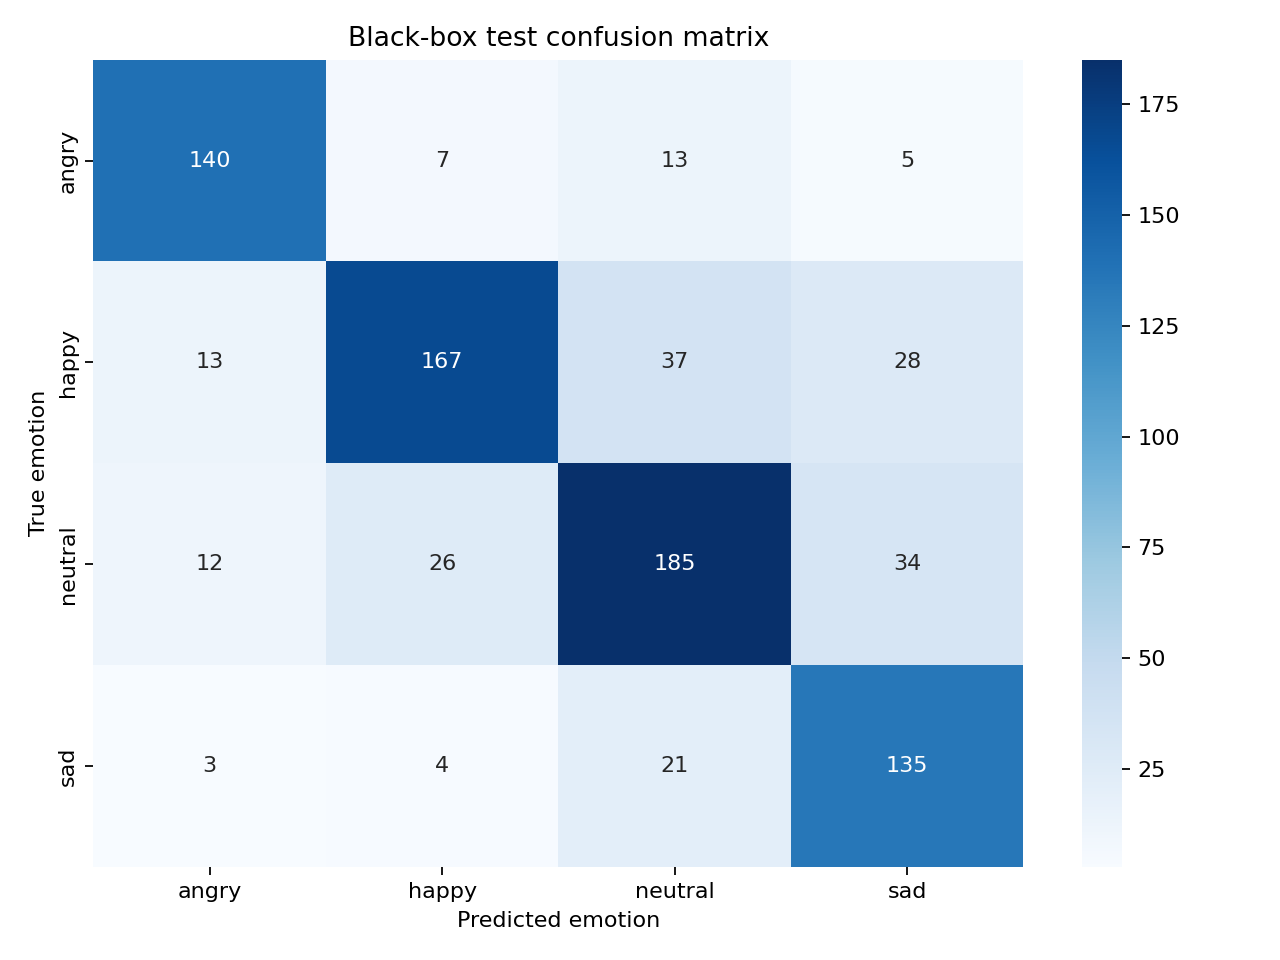

In [7]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


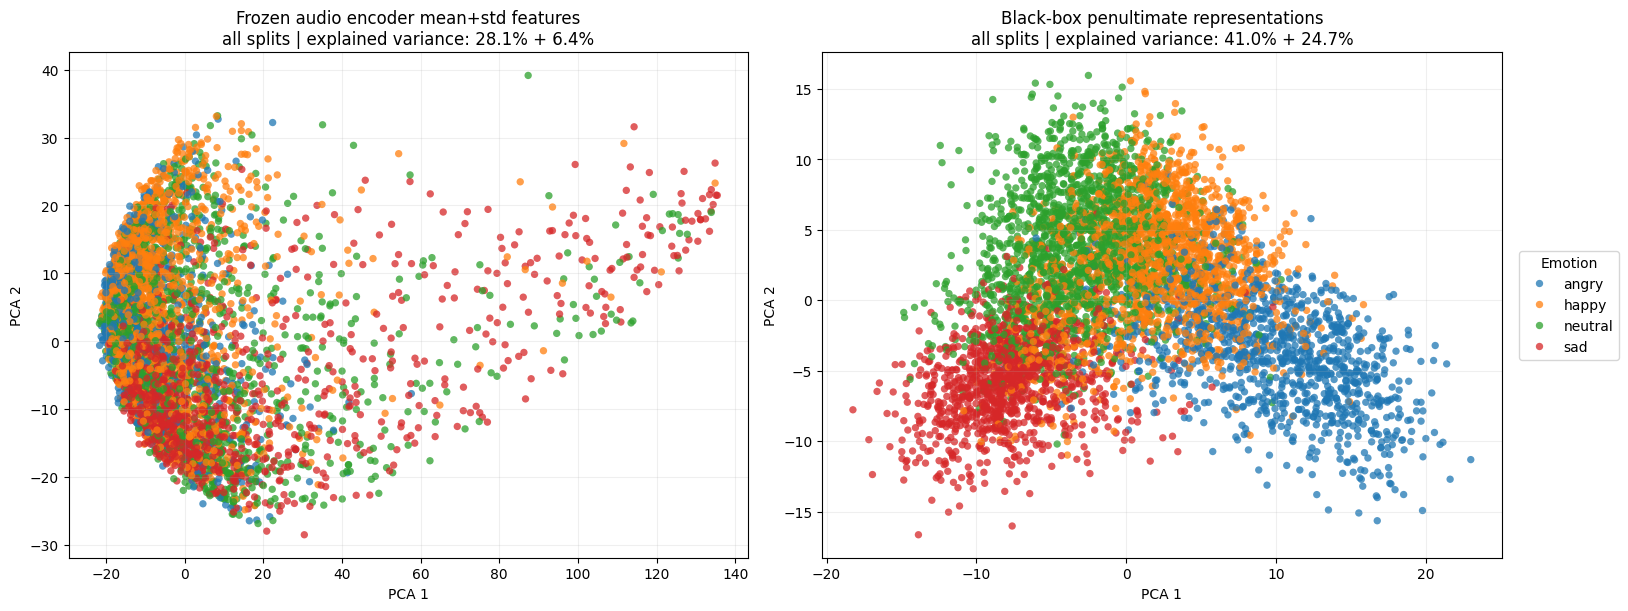

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_iemocap_4class_wavlm_large_sample_stratified/all_embedding_pca.png')

In [8]:
from src.utils.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)

embedding_pca_result["output_path"]

## 8. Extract Black-Box Penultimate Embeddings

Extract the representation before the final black-box classification layer and save its L2-normalized version.

In [9]:
from src.preprocessing.extract_blackbox_embeddings import extract_blackbox_penultimate_embeddings_l2

blackbox_embedding_paths = extract_blackbox_penultimate_embeddings_l2(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    output_dir=BLACK_BOX_EMBEDDING_DIR,
    batch_size=256,
    overwrite=True
)

blackbox_embedding_paths

Extracting black-box penultimate embeddings:   0%|          | 0/22 [00:00<?, ?it/s]

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_iemocap_4class_wavlm_large_sample_stratified_penultimate_l2/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_iemocap_4class_wavlm_large_sample_stratified_penultimate_l2/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_iemocap_4class_wavlm_large_sample_stratified_penultimate_l2/embedding_config.json')}

## 9. Prototype Clustering Grid Search

Fit K-means on the training split only, with K clusters per emotion. Each centroid is mapped to the nearest real training sample of the same emotion, and these real prototypes are used for classification. Select K on the validation split; each vote uses all prototypes available for that K.

In [10]:
from src.data.iemocap import EMOTION_NAMES
from src.training.train_prototype_clustering import (
    PrototypeClusteringTrainingConfig,
    train_prototype_clustering
)

prototype_training_config = PrototypeClusteringTrainingConfig(
    embedding_dim=LAYER_DIMS[-1],
    num_classes=len(EMOTION_NAMES),
    cluster_counts=(1, 2, 3, 4, 5, 6),
    monitor_metric="macro_f1",
    random_state=RANDOM_STATE
)

prototype_training_results = train_prototype_clustering(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    output_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    config=prototype_training_config
)

K=01, all prototypes=04 | val acc 0.7253, macro F1 0.7297, weighted F1 0.7237
K=02, all prototypes=08 | val acc 0.7108, macro F1 0.7148, weighted F1 0.7080
K=03, all prototypes=12 | val acc 0.7169, macro F1 0.7199, weighted F1 0.7148
K=04, all prototypes=16 | val acc 0.7169, macro F1 0.7207, weighted F1 0.7145
K=05, all prototypes=20 | val acc 0.7096, macro F1 0.7132, weighted F1 0.7069
K=06, all prototypes=24 | val acc 0.7229, macro F1 0.7272, weighted F1 0.7213

Best prototype clustering configuration
  K:           1
  Prototypes:  4 used for voting
  Validation:  accuracy 0.7253, macro F1 0.7297, weighted F1 0.7237


## 10. Evaluate Prototype Clustering Classifier

In [11]:
from src.evaluation.evaluate_prototype_clustering import evaluate_prototype_clustering
from src.evaluation.metrics import print_classification_metrics

prototype_test_metrics = evaluate_prototype_clustering(
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    split="test",
    output_dir=PROTOTYPE_CLUSTERING_REPORT_DIR
)

print_classification_metrics(prototype_test_metrics)

Accuracy:    0.7518
Macro F1:    0.7567
Weighted F1: 0.7499

Classification report:
emotion precision recall f1_score  support
  angry    0.7857 0.8667   0.8242      165
  happy    0.8274 0.6653   0.7376      245
neutral    0.7555 0.6732   0.7119      257
    sad    0.6532 0.8896   0.7532      163


## 11. Evaluate Prototype Surrogate Fidelity

Measure how often the clustering surrogate matches the black-box predictions on the test split.

In [12]:
from src.explainability.surrogate_fidelity import print_clustering_surrogate_fidelity_accuracy

surrogate_fidelity_metrics = print_clustering_surrogate_fidelity_accuracy(
    blackbox_checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    prototype_model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test"
)

Accuracy against black-box predictions: 0.9410 (781/830)


## 12. Visualize Prototype Embedding Space

Project the saved L2-normalized black-box embeddings to two PCA dimensions and highlight the prototypes of each emotion.

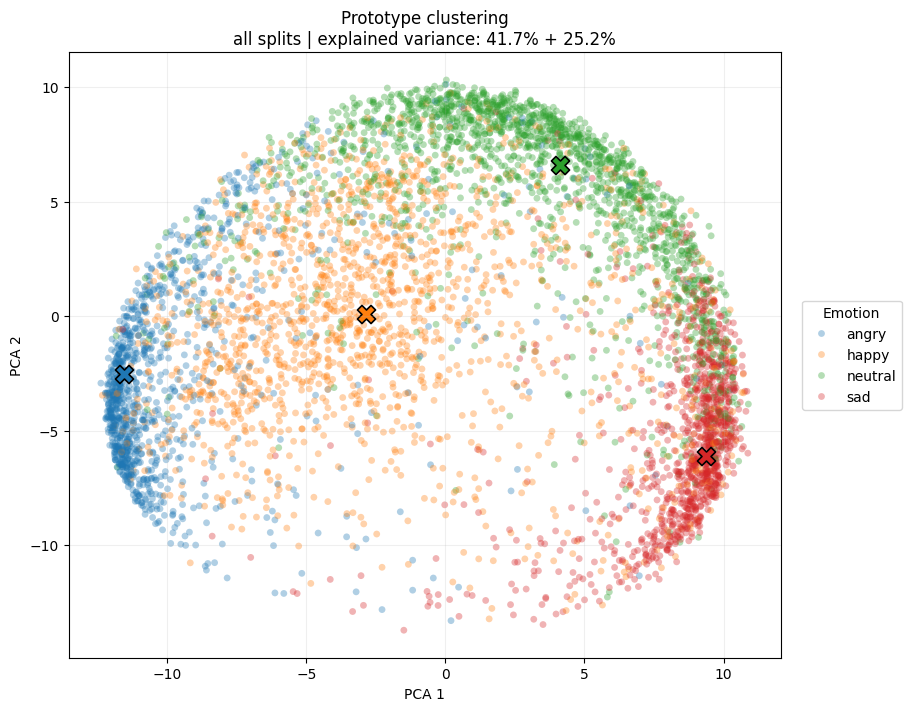

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/prototype_clustering_blackbox_iemocap_4class_wavlm_large_sample_stratified_penultimate_l2/all_prototype_embedding_pca.png')

In [13]:
from src.utils.visualize import plot_prototype_embedding_pca

prototype_pca_result = plot_prototype_embedding_pca(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    split="all",
    output_path=PROTOTYPE_CLUSTERING_REPORT_DIR / "all_prototype_embedding_pca.png",
    random_state=RANDOM_STATE
)

prototype_pca_result["output_path"]

## 13. Explanation By Example - Inspect Prototype Neighbors of a Test Sample

In [14]:
import pandas as pd
from src.explainability.prototype_neighbors import (
    explain_sample_by_filename,
    print_prototype_explanation
)

# Set an IEMOCAP file name here, or leave it as None to sample a different random test example at each rerun.
SAMPLE_TO_EXPLAIN = None

prototype_explanation = explain_sample_by_filename(
    embedding_metadata=pd.read_csv(BLACK_BOX_EMBEDDING_DIR / "metadata.csv"),
    sample_to_explain=SAMPLE_TO_EXPLAIN,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR
)

print_prototype_explanation(prototype_explanation)

Sample:    Session3_00478.wav
True:      angry
Predicted: angry

Class scores:
    angry: 0.9392
    happy: 0.2029
  neutral: -0.0205
      sad: -0.1728

All 4 voting prototypes, sorted by similarity:
  #01   angry | sim 0.9392 | Session3_00226.wav
  #02   happy | sim 0.2029 | Session2_00651.wav
  #03 neutral | sim -0.0205 | Session3_00749.wav
  #04     sad | sim -0.1728 | Session4_00008.wav


We can listen to the test sample and its nearest prototypes (medoids).

In [20]:
from IPython.display import Audio, display, Markdown

sample_file = prototype_explanation["file_name"]
display(Markdown(f"### Sample: `{sample_file}`"))
display(Audio(filename=str(AUDIO_DIR / sample_file)))

display(Markdown("### Top prototypes"))
for prototype in prototype_explanation["top_prototypes"]:
    prototype_file = prototype.get("prototype_file_name")

    display(Markdown(
        f"**#{prototype['rank']} | {prototype['prototype_emotion']} | "
        f"similarity: {prototype['similarity']:.4f}**  \n"
        f"`{prototype_file}`"
    ))
    display(Audio(filename=str(AUDIO_DIR / prototype_file)))

### Sample: `Session3_00478.wav`

### Top prototypes

**#1 | angry | similarity: 0.9392**  
`Session3_00226.wav`

**#2 | happy | similarity: 0.2029**  
`Session2_00651.wav`

**#3 | neutral | similarity: -0.0205**  
`Session3_00749.wav`

**#4 | sad | similarity: -0.1728**  
`Session4_00008.wav`